In [1]:
import pandas as pd
import os

# Scratch file for interactively visualizing *parallel-ml-bench* data (MPL across core counts)

DATA_ROOT = 'data'
TEST_FILE = 'test_mpl_cores:260815-120506:home:ab3c6b6692273c761927291bb65dbe256fd5ee64:260815-120506.processed.jsonl'

def load_df(fname):
    df = pd.read_json(os.path.join(DATA_ROOT, fname), lines=True)
    return df

df = load_df(TEST_FILE)
df

,tag,bench,args,config,cwd,exp,trials,procs,cmd,host,timestamp,elapsed,returncode,binary_bytes,binary_md5,warmup_result_secs,test_results_secs,compiler_md5
0,primes,primes,-N 100000000,mpl-tuple,mpl,time,1,1,/usr/bin/time -v bin/primes.mpl-tuple.bin @mpl...,home,2015-08-26 12:05:13.386900,19.230145,0,808104,03cc1f2f0ec7523181f5cf1b37cb59e1,"[0.6901, 0.6907, 0.6774, 0.6959000000000001, 0...","[0.6890000000000001, 0.6933, 0.6865, 0.6787000...",c0c52981b472f904937a6440b85168f2
1,primes,primes,-N 100000000,mpl-tuple,mpl,time,1,2,/usr/bin/time -v bin/primes.mpl-tuple.bin @mpl...,home,2015-08-26 12:05:32.619083,13.455066,0,808104,03cc1f2f0ec7523181f5cf1b37cb59e1,"[0.4118, 0.4107, 0.40850000000000003, 0.4027, ...","[0.41240000000000004, 0.4106, 0.4071, 0.4062, ...",c0c52981b472f904937a6440b85168f2
2,bfs,bfs,../inputs/rmat-10M-symm-bin --no-dir-opt,mpl-tuple,mpl,time,1,1,/usr/bin/time -v bin/bfs.mpl-tuple.bin @mpl pr...,home,2015-08-26 12:05:46.076302,124.257111,0,1041896,91791d899d39743105b366fa2bd176eb,[5.8143],"[5.9069, 5.7671, 5.8354, 5.7874, 5.7229, 5.827...",c0c52981b472f904937a6440b85168f2
3,bfs,bfs,../inputs/rmat-10M-symm-bin --no-dir-opt,mpl-tuple,mpl,time,1,2,/usr/bin/time -v bin/bfs.mpl-tuple.bin @mpl pr...,home,2015-08-26 12:07:50.335771,66.667405,0,1041896,91791d899d39743105b366fa2bd176eb,"[3.0139, 2.9754]","[2.9692, 2.9637000000000002, 2.9276, 3.0081, 2...",c0c52981b472f904937a6440b85168f2
4,primes,primes,-N 100000000,mpl-baseline,mpl,time,1,1,/usr/bin/time -v bin/primes.mpl-baseline.bin @...,home,2015-08-26 12:08:57.006106,19.688240,0,886144,f7949c864a7092b221485a3f3e3e0f85,"[0.6952, 0.7056, 0.6861, 0.6751, 0.7225, 0.746...","[0.7155, 0.6876, 0.721, 0.679, 0.6808000000000...",c0c52981b472f904937a6440b85168f2
5,primes,primes,-N 100000000,mpl-baseline,mpl,time,1,2,/usr/bin/time -v bin/primes.mpl-baseline.bin @...,home,2015-08-26 12:09:16.696627,13.488597,0,886144,f7949c864a7092b221485a3f3e3e0f85,"[0.41150000000000003, 0.418, 0.402400000000000...","[0.4076, 0.4072, 0.41440000000000005, 0.413500...",c0c52981b472f904937a6440b85168f2
6,bfs,bfs,../inputs/rmat-10M-symm-bin --no-dir-opt,mpl-baseline,mpl,time,1,1,/usr/bin/time -v bin/bfs.mpl-baseline.bin @mpl...,home,2015-08-26 12:09:30.187451,122.682824,0,1082440,b4857aa3b58ab1d5a62576bdc07089f9,[5.7449],"[5.8479, 5.6788, 5.7524, 5.7356, 5.6489, 5.758...",c0c52981b472f904937a6440b85168f2
7,bfs,bfs,../inputs/rmat-10M-symm-bin --no-dir-opt,mpl-baseline,mpl,time,1,2,/usr/bin/time -v bin/bfs.mpl-baseline.bin @mpl...,home,2015-08-26 12:11:32.873116,65.709570,0,1082440,b4857aa3b58ab1d5a62576bdc07089f9,"[2.9917, 2.9269]","[2.9259, 2.9352, 2.8936, 2.9539, 2.9116, 2.879...",c0c52981b472f904937a6440b85168f2


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from dataclasses import dataclass
from IPython.display import display
import os

# Use system latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

CHARTS_ROOT = 'charts/'

CHECKSUM_FIELD = 'binary_md5'
COMPILER_NAME_FIELD = 'config'

def safe_std(all_abs_ratios):
    # np.atleast_1d converts a scalar like 5 into an array [5]
    # If it is already a list, it converts it to a 1D array
    arr = np.atleast_1d(all_abs_ratios)
    
    # Sample standard deviation is undefined for N <= 1, so return 0
    if len(arr) <= 1:
        return 0.0

    # ddof=1 calculates the sample standard deviation; omit it for population stddev
    return np.std(arr, ddof=1)


# Plots data across core counts (procs) from the parallel-ml-bench suite
def plot_parallel_bench_cores(df, values='test_results_secs', title='', out_filename='', abbrevs=None):
    # 1. Find the benchmarks where the compiled binary has a differing hash
    filtered = df[df.groupby('bench')[CHECKSUM_FIELD].transform('nunique') > 1]
    if filtered.empty:
        print("No benchmarks with differing binary hash found.")
        return

    # Infer baseline and test configurations if not explicitly specified
    if abbrevs is None:
        configs = set(filtered[COMPILER_NAME_FIELD].dropna().unique())
        baselines = [c for c in configs if 'baseline' in c]
        if len(baselines) == 1:
            base_key = baselines[0]
            test_keys = [c for c in configs if c != base_key]
            if len(test_keys) == 1:
                abbrevs = (base_key, test_keys[0])
            else:
                raise ValueError(f"Expected exactly 1 test configuration after removing '{base_key}', found {len(test_keys)}: {test_keys}")
        elif len(configs) == 2:
            abbrevs = tuple(sorted(list(configs)))
        else:
            raise ValueError(f"Could not automatically determine baseline and test configs from: {configs}")

    base_key, test_key = abbrevs[0], abbrevs[1]
    filtered = filtered[filtered[COMPILER_NAME_FIELD].isin([base_key, test_key])]
    
    # 2. Among benchmarks with a differing hash, collect all runs according to their core-count ("procs")
    filtered = filtered.drop_duplicates(subset=['bench', 'procs', COMPILER_NAME_FIELD], keep='last')
    pivot = filtered.pivot(index=['bench', 'procs'], columns=COMPILER_NAME_FIELD, values=values)
    pivot = pivot.dropna(subset=[base_key, test_key])

    # 3. Calculate the base-vs-test ratio for each core-count, plus a stddev
    all_abs_ratios = pivot.apply(
        lambda row: np.array(row[test_key]) / np.array(row[base_key]),
        axis=1
    )
    mean_abs_ratios = all_abs_ratios.apply(np.mean)
    std_abs_ratios = all_abs_ratios.apply(safe_std)

    results_df = pd.DataFrame({
        'bench': [idx[0] for idx in pivot.index],
        'procs': [idx[1] for idx in pivot.index],
        'mean_ratio': mean_abs_ratios.values,
        'std_ratio': std_abs_ratios.values,
        'relative_pct': (mean_abs_ratios.values - 1) * 100,
        'std_pct': std_abs_ratios.values * 100,
    })

    # 5. Add an additional series for the geomean speedup at each core count
    geomean_per_proc = results_df.groupby('procs')['mean_ratio'].apply(
        lambda s: np.exp(np.mean(np.log(s.dropna())))
    )
    geomean_pct = (geomean_per_proc - 1) * 100

    # 4. Plot data as a line chart, with each series corresponding to a benchmark, marking stddev with error bar
    fig, ax = plt.subplots(figsize=(8, 5))
    markers = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']
    benches = sorted(results_df['bench'].unique())

    for i, bench in enumerate(benches):
        bench_data = results_df[results_df['bench'] == bench].sort_values('procs')
        marker = markers[i % len(markers)]
        ax.errorbar(
            bench_data['procs'],
            bench_data['relative_pct'],
            yerr=bench_data['std_pct'],
            label=bench,
            marker=marker,
            capsize=3,
            capthick=1,
            linewidth=1.5,
            markersize=5,
            alpha=0.85
        )

    # Dotted line for Geomean series
    ax.plot(
        geomean_per_proc.index,
        geomean_pct.values,
        label='Geomean',
        linestyle=':',
        color='black',
        marker='D',
        linewidth=2.5,
        markersize=6,
        zorder=10
    )

    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

    unique_procs = sorted(results_df['procs'].unique())
    if len(unique_procs) > 2 and all(p > 0 for p in unique_procs) and max(unique_procs) / min(unique_procs) >= 8:
        ax.set_xscale('log', base=2)
    ax.set_xticks(unique_procs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

    ax.set_xlabel('Core count (procs)')
    ax.set_ylabel(r'Relative \% $\frac{\mathrm{test}}{\mathrm{base}} - 1 \times 100\%$')
    ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    if title:
        ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='best')

    plt.tight_layout()
    if out_filename:
        os.makedirs(CHARTS_ROOT, exist_ok=True)
        path = os.path.join(CHARTS_ROOT, f'{out_filename}.pdf')
        print(f'NOT saving chart to {path}')
        # print(f'Saving chart to {path}')
        # plt.savefig(path, format='pdf', bbox_inches='tight')
    plt.show()

In [3]:
@dataclass(frozen=True)
class PlotConfig:
    values_column: str
    title: str
    out_filename: str

FLAVOR_NAME = 'parallel_ml_bench'

def plot_mpl_vs_mpl(data, type_name):
    print(f'Plotting file for {type_name} (MPL vs MPL across cores): {data}')
    df = load_df(data)
    configs = [
        PlotConfig(values_column='test_results_secs',
                   title=f'{type_name.capitalize()} run time comparison across core counts', 
                   out_filename=f'{type_name}_{FLAVOR_NAME}_run_mpl_vs_mpl_cores'),
    ]
    for c in configs:
        plot_parallel_bench_cores(df, values=c.values_column, title=c.title, out_filename=c.out_filename)

def plot_parallel_bench_tuple_mpl_vs_mpl():
    fname = 'test_mpl_cores:260815-120506:home:ab3c6b6692273c761927291bb65dbe256fd5ee64:260815-120506.processed.jsonl'
    plot_mpl_vs_mpl(fname, 'tuple')

Plotting file for tuple (MPL vs MPL across cores): test_mpl_cores:260815-120506:home:ab3c6b6692273c761927291bb65dbe256fd5ee64:260815-120506.processed.jsonl
NOT saving chart to charts/tuple_parallel_ml_bench_run_mpl_vs_mpl_cores.pdf


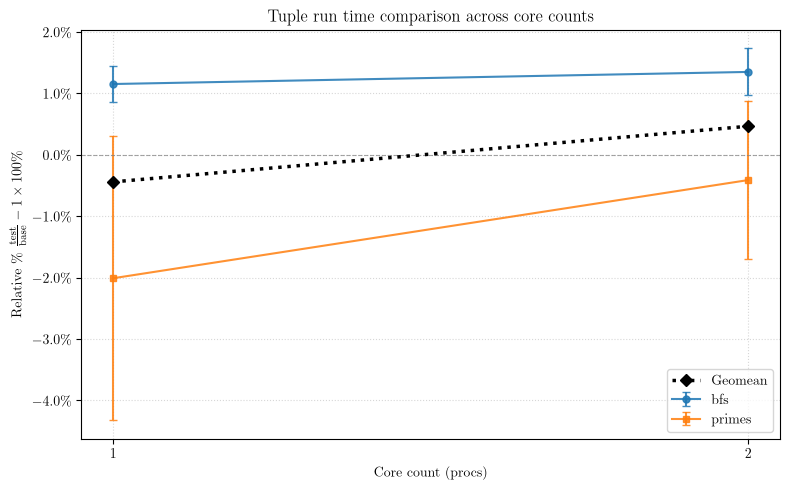

In [4]:
plot_parallel_bench_tuple_mpl_vs_mpl()